# **Descrição do algoritmo**




In [ ]:
#Imports gerais
import numpy as np
import cv2
import sys
from PIL import Image, ImageDraw, ImageFont


#Imports do colab
from google.colab.patches import cv2_imshow
from google.colab import files



In [ ]:
# Liga os blocos de Debug. Serve para visualização de imagens intermediárias e máscaras.
# Aumenta significativamente o tempo de execução do código já que ele imprime imagens com resolução alta várias vezes.
# Não é necessário para o funcionamento do código, apenas para visualização do que está acontecendo internamente.

Debug = True

In [ ]:
def formatRes(r):
    omega = "\u03A9"

    if r < 1e3:
        return f'{r:.0f} {omega}'
    elif r < 1e6:
        return f'{r/1e3:.1f} k{omega}'
    elif r < 1e9:
        return f'{r/1e6:.1f} M{omega}'
    else:
        return f'{r/1e9:.1f} G{omega}'

A função colorDec() é a função criada para decidir a cor do pixel em sua entrada.

A função tem duas variáveis de entrada: cor e canBlack, essa última tendo o valor True como padrão. A função de canBlack é explicada com mais detalhes mais a frente no código. Entretanto, de forma sucinta, ela verifica se a cor pode ou não ser avaliada como preta.

A variável cor é o pixel em HSV que está para ser avaliado. Ele contém as informações de *hue*, *saturation* e *value* do pixel.

No início da função, o dicionário centro cores é definido. Ele armazena a cor e o valor *hue* (H) de cada cor. As corers dentro do dicionário são muito bem definidas apenas pelo seu valor de H. Inicia então um loop que itera pelas chaves e por seus valores. Com o valor H do pixel extraído, para cada iteração do laço, a distância entre o H do pixel e o H da cor é calculada. Se a distância até a cor calculada for a menor até aquele laço a distância é armazeada em menor_dist e a cor é armazenada em melhor_cor. Ao fim do laço a cor salva será aquela que a distância entre Hs foi a menor.

Em sequência, é verificada a viabilidade da cor ser cinza, preta ou marrom. Na teoria do espaço HSV a cor cinza é definida como uma cor com um valor qualquer de *hue*, um valor muito baixo de *saturation* (S) e um valor moderado de *value*(V). Já a cor preta é simplismente definida como uma cor com qualquer valor de H e de S mas com valor de V muito baixo. E a cor marrom é definido como um Vermelho ou Laranja com valor baixo de V. Entretanto, a saturação (*saturation*) e brilho (*value*) de uma foto, diferentemente do *hue*, podem ser alterados dependendo das condições em que ela foi tirada. Assim, o que é "V muito baixo", "S muito baixo" e "V moderado" se torna subjetivo, não sendo possível simplesmente calcular a distância entre valores.

Para então decidir se a cor era preto, cinza ou marrom foram criados limiares e condições *if* e *else*.

Os limiares foram ajustados utilizado um conjunto de fotos chamadas de conjunto de calibração. Assim, os limiares foram ajustados até que quando o programa foi aplicado a grande parte das fotos separadas para o conjunto de calibração, o resultado obtido fosse correto. Portanto, a lógica das condições é simples:


*   Verifica se a saturação e o brilho se encaixam nos limiares para verificar se a cor pode ser cinza,
*   Caso não, verifica se somente o brilho se encaixa nos limiares para verificar se a cor pode ser preta,
*   Caso não entre em condção alguma, a cor obtida anteriormente, pelo cálculo da dstância entre Hs é retornada.
*   No caso especial da cor ser Vermelho ou Laranaja, testa-se a viabilidade da cor ser também Marrom.



In [ ]:
def colorDec(cor,canBlack = True):
# Verificar centros usando resistores.

    centroCores = {
        'Vermelho':[0,179],
        'Laranja': 10,
        'Amarelo':25,
        'Verde':50,
        'Azul':110,
        'Violeta':130
    }

    melhor_cor = None
    menor_dist = float('inf')
    hcor = cor[0]
    for nome, centro in centroCores.items():

        if nome == 'Vermelho':
          dist1 = np.linalg.norm(np.array(hcor) - np.array(centro[0]))
          dist2 = np.linalg.norm(np.array(hcor) - np.array(centro[1]))
          dist = min(dist1,dist2)

        else:
          dist = np.linalg.norm(
              np.array(hcor) - np.array(centro)
          )

        if dist < menor_dist:
            menor_dist = dist
            melhor_cor = nome

    if melhor_cor == 'Vermelho' or melhor_cor == 'Laranja':
            if (cor[1] < 70 and (30 < cor[2] < 60)) or (cor[1] < 20 and (40 < cor[2] < 100)):
                if cor[2] < 30 and canBlack:
                    melhor_cor = 'Preto'

                else:
                    melhor_cor = 'Cinza'

            elif cor[2] < 70:
                if cor[2] < 15 and canBlack:
                    melhor_cor = 'Preto'

                else:
                    melhor_cor = 'Marrom'

            elif cor[2] > 100:
                melhor_cor = 'Laranja'

    else:
            if (cor[1] < 70 and cor[2] < 60) or (cor[1] < 20 and cor[2] < 100):
                if cor[2] < 30 and canBlack:
                    melhor_cor = 'Preto'

                else:
                    melhor_cor = 'Cinza'

            elif cor[2] < 20 and canBlack:
                melhor_cor = 'Preto'

    print(melhor_cor, menor_dist)
    return melhor_cor

In [ ]:
def resistencia(cores):

  colorcode = {'Preto':0,
               'Marrom':1,
               'Vermelho':2,
               'Laranja':3,
               'Amarelo':4,
               'Verde':5,
               'Azul':6,
               'Violeta':7,
               'Cinza':8,
               }
  holder = []

  for cor in cores:
    holder.append(colorcode[cor])


  resist = (holder[0]*10 + holder[1])*10**(holder[2])
  resist = formatRes(resist)
  return resist
  print(f'Seu resistor é de {resist} omhs! ')


# **Segmentação do Resistor**
O trecho abaixo carrega a imagem com o resistor no código.
Após carregado, converte a imagem para o espaço HSV onde aplica um tratamento
de clareamento da imagem. Isso remove o escurecimento causado no fundo pela
claridade do ambiente onde a foto foi tirada, possibilitando que o resistor
seja encontrado na imagem usando operações de limiarização simples.

In [ ]:

res_num = input('Qual número do res: ')
# img = cv2.imread(f'/content/drive/MyDrive/Projeto - Resistores/Testes/IMG_16{res_num}.png')
# img = cv2.imread(f'/content/drive/MyDrive/Projeto - Resistores/Fernando/Resistor_{res_num}.png')
img = cv2.imread(f'/content/drive/MyDrive/Projeto - Resistores/Resistores/Resistor_{res_num}.png')

# uploadImg = files.upload()
# imgFile = next(iter(uploadImg))
# img = cv2.imread(imgFile)


hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h,s,v = cv2.split(hsv)

v = cv2.GaussianBlur(v,(5,5),0)
bg = cv2.GaussianBlur(v,(101,101),0)
v2 = cv2.divide(v,bg,scale=255)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
v2 = clahe.apply(v2)
final = cv2.merge((h,s,v2)) #Imagem com fundo muito claro para limiarização.

Qual número do res: 19


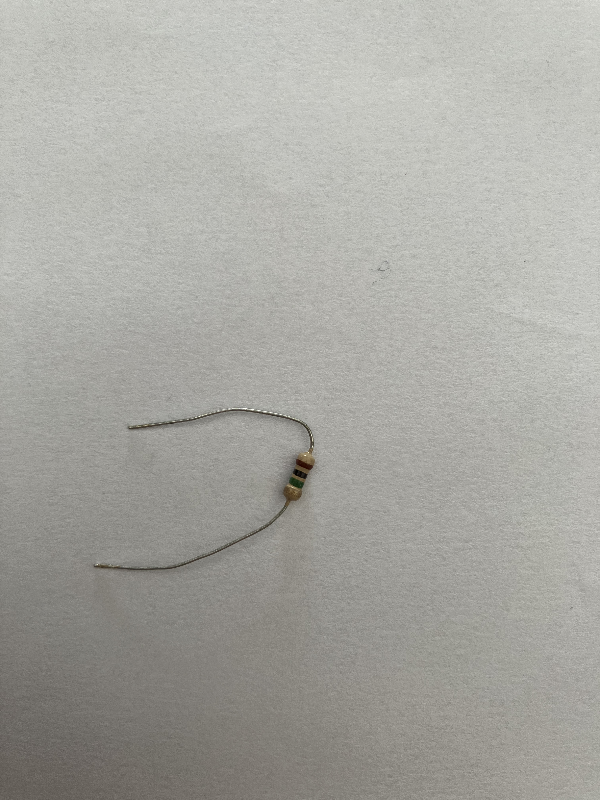

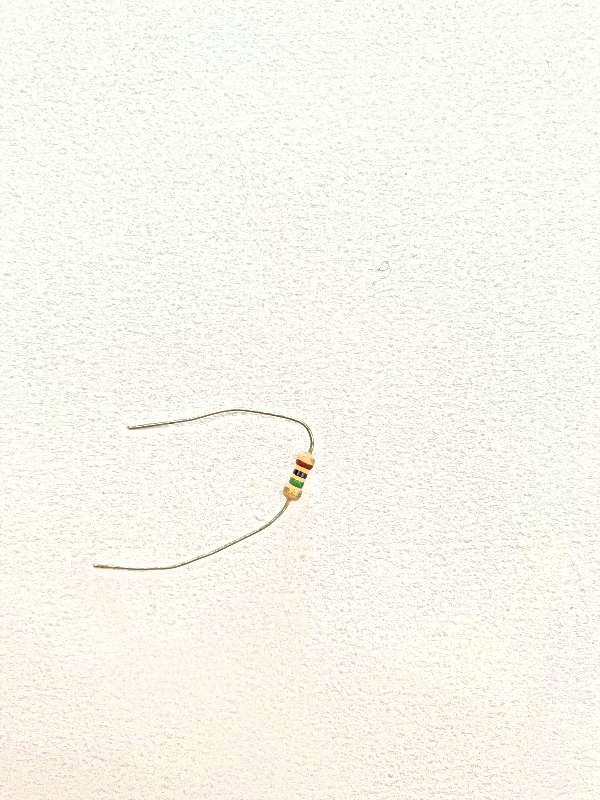

In [ ]:
if Debug == True:
  cv2_imshow(cv2.resize(img,(600,800))) #Imagem original (tamanho alterado para visualização)
  finalDebug = cv2.cvtColor(final, cv2.COLOR_HSV2BGR)
  cv2_imshow(cv2.resize(finalDebug,(600,800))) #Imagem clareada (tamanho alterado para visualização)

No trecho abaixo é realizado o procedimento que encontra o resistor na imagem.
Dois limiares são definidos: um superior e um inferior. A função cvt.inRange irá pegar os limiares definidos, assim como a imagem salva na variavel final e tornar todos os pixels dentro da faixa brancos e todos fora pretos. Depois faz um fechamento e uma abertura morfológica com kernel de 5x5 pixels. A operação de fechamento irá unir pixels próximos do corpo do resistor caso a limiarização tenha separado-os e a abertura irá limpar os pixels de ruído. O resultado é uma máscara com o corpo do resistor e algum ruído que ainda irá sobrar mas terá seu tamanho reduzido pela operação de abertura em branco e com o fundo preto.


In [ ]:
                #[H, S, V]
lower = np.array([0, 0, 170])
upper = np.array([180, 45, 255])
background = cv2.inRange(final, lower, upper)

# Inverte
mask = cv2.bitwise_not(background)

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5,5)
)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel
)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_OPEN,
    kernel
)


In [ ]:
if Debug == True:
  cv2_imshow(mask) #Máscara com ruído

Em seguida, utilizanndo a máscara, obtem-se os contornos do que foi extraído e escolhe o contorno de maior área. Caso a foto tirada respeite as condições do algoritmo (fundo branco, sem sombra de outros objetos sobre a imagem e pouca sombra do resistor), o contorno com maior área será justamente o contorno do corpo do resistor. Assim, cria-se uma nova máscara somente com o corpo do resistor, eliminando qualquer outro ruído.

In [ ]:

contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_escolhido = max(contornos, key=cv2.contourArea)
mask = np.zeros(final.shape[:2], dtype=np.uint8)
cv2.drawContours(mask, [contorno_escolhido], -1, 255, -1);


In [ ]:
if Debug == True:
  cv2_imshow(mask) #Máscara somente com o resistor

O procedimento anterior não remove as pernas do resistor, que podem vir a atrapalhar a leitura do código de cores. A estratégia adotada para remover as pernas usa de um algorítmo sobre a máscara chamado *Distance Transforme*. Esse algoritmo calcula a distância de cada pixel branco na máscara até o pixel preto mais próximo. No caso da máscara do resistor, os pixels da perna estarão muito próximos do fundo preto enquanto os pixels mais internos do corpo estarão distantes do fundo. Feito esse cálculo, obtem-se o valor máximo retornado pelo algoritmo e utilaza-se desse valor para criar um kernel que será utilizado em uma abertura morfológica. O lado do kernel terá o terá cada lado medindo aproximadamente o raio do corpo do resistor (a distância máxima obtida pela *Distance Transforme*), que será pequeno comparado ao corpo como um todo mas muito grande comparado com o raio das pernas. Ao realizar a abertura, as pernas são removidas enquanto o corpo do resistor é completamente preservado. Ao fim, o trecho salva a máscara que indica somente o corpo sem as pernas do resistor em uma variável para ser utilizada na sequência.

In [ ]:

radius = cv2.distanceTransform(mask, cv2.DIST_L2, 5).max()

L =int( radius if radius%2 > 0 else radius+ 1 )
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (L, L)
)


opening = cv2.morphologyEx(
    mask,
    cv2.MORPH_OPEN,
    kernel)

resistor = opening


In [ ]:
if Debug == True:
  cv2_imshow(resistor) #Máscara com o resistor sem as pernas

Obtida máscara, aplica-se sobre a imagem original, obtendo uma imagem com o resistor e com fundo preto. Em seguida, extrai-se a *Bouding Box* do resistor, para obter suas dimensões, sua posição na imagem e seu ângulo. A ideia é, utilizando as informações obtidas, colocar o resistor na posição horizontal e realizar a seguimentação das faixas do código de cores a partir daí. Dessa forma, rotacionam-se 3 imagens: A imagem original (imgRotac2), a imagem com o corpo do resistor seguimentado (imgRotac) e a máscara (resistor).

In [ ]:
resultado = cv2.bitwise_and(img, img, mask=resistor)

ContRes, _ = cv2.findContours(resistor, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
rect = cv2.minAreaRect(max(ContRes, key=cv2.contourArea))

(cx_rect, cy_rect), (w, h), angle = rect


if w < h:
    angle = angle + 90

M = cv2.getRotationMatrix2D((cx_rect, cy_rect), angle, 1.0)

imgRotac = cv2.warpAffine(
    resultado,
    M,
    (resultado.shape[1], resultado.shape[0]),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(0, 0, 0)
)

imgRotac2 = cv2.warpAffine(
    img,
    M,
    (img.shape[1], img.shape[0]),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(0, 0, 0)
)

resistor = cv2.warpAffine(
    resistor,
    M,
    (resistor.shape[1], resistor.shape[0]),
    flags=cv2.INTER_NEAREST,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=0
)


In [ ]:
if Debug == True:
  cv2_imshow(cv2.resize(imgRotac, (600,800)))  #Imagem após aplicação da máscara rotacionada
  cv2_imshow(cv2.resize(imgRotac2, (600,800))) #Imagem original rotacionada
  cv2_imshow(cv2.resize(resistor, (600,800)))  #Máscara rotacionada

# **Segmentação das faixas do código de cores**
Rotacionadas as imagens, ciram-se algumas cópias e configurações para serem utilizadas na segmentação das faixas coloridas.

Primeiro, uma cópia suavizada da imagem original para remover alguns ruídos e uniformizar a cor dos pixels das faixas.

Em sequência, converte-se a imagem suavizada para o espaço HSV e obtém-se cada componente (hue, saturation, value) de forma separada.

Por fim, obtém-se um novo kernel que será utilizado nas operações morfológicas das máscaras utilizadas para segmentar as faixas. O kernel é constituido de um lado com 20% do lado utilizado para contruir o kernel anterior.

In [ ]:

blur = cv2.GaussianBlur(imgRotac2, (11,11), 0)
blur = cv2.bitwise_and(blur,blur,mask = resistor)

corpohsv = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)
hc,sc,vc = cv2.split(corpohsv)

LFaixas =int( L*0.2 if radius%2 > 0 else L*0.2+ 1 )
kernelFaixas = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (LFaixas, LFaixas)
)

Inicia-se a construção da primeira máscara, baseada exclusivamente no valor de *hue* do corpo do resistor. Em hcc são armazenados os pixels de hc correspondentes às posições em que a máscara resistor é maior que zero. Em seguida, calcula-se o histograma desses valores e salva-se em maxh o valor de H mais frequente.

Utilizando esse valor e a função cv2.inRange(), cria-se a máscara maskhInv, que é branca apenas nas regiões cujos pixels possuem valor de H próximo de maxh. A partir dela, obtém-se maskh, que passa a ser branca nas regiões com valores de H distantes daquele predominante no corpo do resistor.

Por fim, utiliza-se de uma abertura morfológica para separar faixas que possivelmente tenham saído "coladas" após o filtro.

O procedimento baseia-se na premissa de que o valor de *hue* mais frequente corresponde à cor do corpo do resistor, geralmente bege. Dessa forma, idealmente, maskhInv contém apenas o corpo do resistor em branco, enquanto maskh contém apenas as faixas do código de cores. Entretanto, o método pode filtrar faixas cujos valores de *hue* sejam semelhantes aos do corpo. Em um resistor bege, por exemplo, os valores de *hue* do bege e do amarelo são muito próximos, sendo diferenciados principalmente pelos demais eixos do espaço HSV, *saturation* e *value*. Por esse motivo, outras máscaras são construídas para garantir uma segmentação adequada.


In [ ]:
hcc = hc[resistor>0]

histh = cv2.calcHist([hcc],[0],None, [179],[0,179])
maxh = np.argmax(histh)

maskhInv = cv2.inRange(hc, int(maxh - 12), int(maxh + 12)) #Máscara do corpo

maskh = cv2.bitwise_and(
    cv2.bitwise_not(maskhInv),
    resistor
) #Máscara do que não é corpo.

maskh = cv2.morphologyEx(
    maskh,
    cv2.MORPH_OPEN,
    kernelFaixas)

In [ ]:
if Debug == True:
  cv2_imshow(maskh) #Máscara obtida a partir da filtragem da cor com valor H mais proeminente

A segunda máscara criada será a máscara de cores vivas. Essa máscara é construida apenas utilizando os pixels filtrados anteriormente, ou seja, vai extrair as cores vivas apenas dos pixels filtrados pela máscara anterior.

Escolheu-se seguir essa estratégia, pois, de forma geral, as cores das faixas dos resistores costumam ser mais vivas do que a cor do corpo, justamente para que possam ser bem destacadas até mesmo pela nossa visão.

Primeiro, salva-se em sb, apenas o valores de *saturation* dos pixels da imagem suavizada onde a máscara do que é corpo (maskhInv) é maior do que 1.

Na sequência, utiliza-se da função cv2.Threshold() para criar a máscara masks. A função faz que todos os pixels de sb com valor maior que 150 se tornem pixels brancos e todos com valor menor se tornem pixels preto.

Novamente, aplica-se uma abertura para separa faixas que possam ter ficado coladas.

Por fim, cria-se a máscara maskf, a soma das duas obtidas até o momento.

Para essa máscara, escolheu-se o limiar fixo de 150, pois, diferentemente do *hue*, o valor de *saturation* do corpo não é bem concentrado em torno de um valor, mas sim distribuidos em valores baixos. O valor de 150 foi obtido a partir da análise de fotos do grupo de calibração (também utilizado para desenvolvimento da função que decide a cor dos pixels).

In [ ]:
sb = cv2.bitwise_and(sc,sc,mask = maskhInv)

#Extração de cores vivas que foram filtrada como corpo.

_,masks = cv2.threshold(sb,150,255,cv2.THRESH_BINARY)

masks = cv2.morphologyEx(
    masks,
    cv2.MORPH_OPEN,
    kernelFaixas)

maskf = cv2.bitwise_or(maskh,masks)

In [ ]:
if Debug == True:
  cv2_imshow(masks) #Máscara obtida a partir da filtragem do valor de saturação (S)
  cv2_imshow(maskf) #Soma das duas máscaras obtidas

A útlima máscara criada é a máscara de cores escuras. Cores como preto e cinza não tem um valor de H definido, o preto é qualquer pixel com *value* (V) muito baixos, já o cinza, qualquer pixel com *saturation* (S) muito baixa e *value* moderado. Essas cores podem não ser extraídas pela segunda máscara, já que só irá extrair pixels com S elevado. Entretanto, essas cores são facilmente separadas do corpo ao utilizar escala de cinza, já que são mais escuras.

Inicialmente, converte-se a imagem suavizada e obtém a região onde se encontra o resistor.

Novamente utilizando cv2.Threshold(), cria-se maskgInv, contendo somente os pixels claros. Entretanto, com maskgInv, obtém-se maskg, dessa vez com os pixels escuros.

Ao fim, somam-se todas as máscaras de forma a obter maskff, a máscara final com todas as 3 faixas segmentadas corretamente.

In [ ]:
gray = cv2.cvtColor(blur,cv2.COLOR_BGR2GRAY)
gray = cv2.bitwise_and(gray,gray,mask = maskhInv)

#Extração de cores escuras que foram filtradas como corpo.

_,maskgInv = cv2.threshold(gray,50,255,cv2.THRESH_BINARY)

maskg = cv2.bitwise_and(
    cv2.bitwise_not(maskgInv),
    resistor
)

maskg = cv2.morphologyEx(
    maskg,
    cv2.MORPH_OPEN,
    kernelFaixas)

maskff = cv2.bitwise_or(maskf,maskg)

In [ ]:
if Debug == True:
  cv2_imshow(maskg)  #Máscara obtida a partir da filtragem de cores escuras
  cv2_imshow(maskff) #Soma de todas as máscaras obtidas até o momento.

## **Comentário geral sobre as máscaras**

Nos blocos onde as máscaras são obtidas existem alguns trechos tais como:



```
maskg = cv2.bitwise_and(
    cv2.bitwise_not(maskgInv),
    resistor
)
```



Esses trechos são onde são inverrtidas as máscaras quando o conteúdo desejado, na verdade, é o que a limiarização tornou preto. Entretanto, se somente fosse invertido o valor dos pixels, todo o fundo preto da imagem se tornaria branco. Dessa forma, após a inversão, aplica-se a operação *and* pixel a pixel com a máscara resistor, assim, somente os pixels que são brancos tanto na máscara quanto na variável resistor são mantidos, eliminando o fundo que tinha se tornado branco na inversão.

# **Tratamento dos contornos das faixas**
No bloco abaixo, os contornos referentes as faixas segmentadas com as máscaras são extraídos. Idealmente, apenas 3 contornos (1 para cada faixa é extraído). Entretanto, nem sempre isso acontece.

Devido a iluminação, uma faixa branca de luz pode aparecer no meio das faixas do código de cores, fazendo com que a segmentação anterior obtenha a região das faixas mas dividas em duas partes. Essa questão em específica é tratada no bloco após o próximo.

In [ ]:
contornosF, _ = cv2.findContours(maskff, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [ ]:
if Debug == True:
  imgRotacDebug = imgRotac.copy()
  cv2.drawContours(imgRotacDebug, contornosF, -1, (0,255,0),2);
  cv2_imshow(imgRotacDebug)

Para lidar com contornos que representam a mesma faixa o algoritmo abaixo é criado.

Primeiro, dentro do primeiro *for*, ele obtém o centroide de cada contorno e sua área, salvando o contorno, o centroide e a área dentro de um dicionário que é armazenado na variável dados a cada iteração do laço.

No segundo for a lógica utilizada impede que o mesmo contorno seja comparado consigo mesmo, assim como impede que a mesma comparação seja feita mais de uma vez. Caso a diferença dos centros seja menor do que 5, os contornos são considerados pertencentes a mesma faixa e o contorno de menor área é armazenado em remover.

Ao fim, a variável faixas é construída sem os contornos armazanados em remover.


In [ ]:
#Remove contornos na mesma posição X

dados = []

for contorno in contornosF:
    M = cv2.moments(contorno)
    if M["m00"] == 0:
        continue
    cx = M["m10"] / M["m00"]
    area = cv2.contourArea(contorno)
    dados.append({
        "contorno": contorno,
        "cx": cx,
        "area": area
    })


remover = set()
for i in range(len(dados)):
    for j in range(i + 1, len(dados)):
        if abs(dados[i]["cx"] - dados[j]["cx"]) <= 5:
            # Remove o de menor área
            if dados[i]["area"] < dados[j]["area"]:
                remover.add(i)
            else:
                remover.add(j)


faixas = [
    dados[i]["contorno"]
    for i in range(len(dados))
    if i not in remover
]

In [ ]:
if Debug == True:
  imgRotacDebug = imgRotac.copy()
  cv2.drawContours(imgRotacDebug, faixas, -1, (0,255,0),2);
  cv2_imshow(imgRotacDebug)

Apenas 3 faixas do resistor devem ser analisadas para a tomada de decisão do valor de sua resistência. Durante a segmentação das faixas, alguns trechos do corpo do resistor ainda podem aparecer devido a sua saturação, ou por estar mais escuro que o resto. Geralmente esses trechos tem área muito menor que a das faixas encontradas. Dessa forma, a variável faixas é reconstruída apenas com os 3 maiores contornos obtidos anteriormente.

In [ ]:
if len(faixas) >= 3:
  faixas = sorted(
      faixas,
      key=cv2.contourArea,
      reverse=True
  )[:3]

else:
  print('Menos de 3 faixas identificadas. Por favor, tire outra foto.')
  sys.exit()

In [ ]:
if Debug == True:
  imgRotacDebug = imgRotac.copy()
  cv2.drawContours(imgRotacDebug, faixas, -1, (0,255,0),2);
  cv2_imshow(imgRotacDebug)

# **Ordenação das faixas para leitura**
Antes de seguir para o decisor de cores, o algoritmo irá decidir a ordem de leitura das faixas.

A lógica parte do pressuposto que a primeira faixa está mais perto da borda do rersistor do que a última. Uma das limitações do algoritmo é que ele não é capaz de ler a faixa de tolerância. Portanto, a última faixa sempre será a terceira.

O trecho primeiro obtém a *Bouding Box* do resistor (essa é diferente da anterior pois agora o resistor está rotacionado) de forma a obter a posição de suas extremidades (as outras dimensões da caixa serão utilizadas posteriormente no código).

O algoritmo então obtém a posição x do centroide de cada faixa e calcula a distância desse valor até cada borda da caixa do resistor armazenando esses valorres em d_esq e d__dir.

Após isso ele obtém as faixas das extremidades, sem saber ainda qual faixa está mais próxima de cada extremidade. A faixa que sobrar será a do meio.

Em seguida, o algoritmo determina qual das duas faixas das extremidades corresponde à primeira faixa do resistor. Para isso, compara a menor distância de cada faixa extrema até as bordas do corpo do resistor. A faixa que estiver mais próxima de uma extremidade é considerada a primeira faixa, seguindo a premissa de que ela deve estar mais próxima da borda do resistor do que a última faixa.

Com isso, é definida a ordem de leitura das três faixas e criada uma nova lista contendo seus contornos já organizados na sequência correta para as etapas seguintes do algoritmo.

In [ ]:

# Ordena as Faixas para ler o resistor na ordem correta
ContRes, _ = cv2.findContours(resistor, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

x_res, y_res, w_res, h_res = cv2.boundingRect(
    max(ContRes, key=cv2.contourArea)
)

xs = []

# Centroide de cada faixa
for faixa in faixas:
    M = cv2.moments(faixa)

    px = int(M["m10"] / M["m00"])
    xs.append(px)

# Distância até a borda esquerda e direita do resistor
d_esq = [x - x_res for x in xs]
d_dir = [x_res + w_res - x for x in xs]

# Faixas mais à esquerda e mais à direita
argmin = np.argmin(xs)
argmax = np.argmax(xs)

# Faixa do meio
meio = ({0, 1, 2} - {argmin, argmax}).pop()

FdArg1 = [d_esq[argmin], d_dir[argmin]]
FdArg2 = [d_esq[argmax], d_dir[argmax]]

# Quem estiver mais próximo de uma extremidade é a primeira faixa
if min(FdArg1) < min(FdArg2):
    ordem = [argmin, meio, argmax]
else:
    ordem = [argmax, meio, argmin]

FaixasOrdenadas = [faixas[i] for i in ordem]

In [ ]:
if Debug == True:
  imgRotacDebug  = imgRotac.copy()
  imgRotacDebug2 = imgRotac.copy()

  # Retângulo do resistor
  cv2.rectangle(
      imgRotacDebug,
      (x_res, y_res),
      (x_res + w_res, y_res + h_res),
      (0, 255, 0),
      2
  )
  cv2.rectangle(
      imgRotacDebug2,
      (x_res, y_res),
      (x_res + w_res, y_res + h_res),
      (0, 255, 0),
      2
  )

  # Centroides das duas faixas analisadas
  faixas_debug = [0,1,2]

  for idx in faixas_debug:

      M = cv2.moments(faixas[idx])

      px = int(M["m10"] / M["m00"])
      py = int(M["m01"] / M["m00"])

      # Centroide
      cv2.circle(imgRotacDebug, (px, py), 5, (0, 0, 255), -1)
      cv2.circle(imgRotacDebug2, (px, py), 5, (0, 0, 255), -1)


      # Distância até a borda esquerda (d1)
      cv2.line(
          imgRotacDebug,
          (x_res, py),
          (px, py),
          (255, 0, 0),
          2
         )

      # Distância até a borda direita (d2)
      cv2.line(
          imgRotacDebug2,
          (px, py),
          (x_res + w_res, py),
          (0, 255, 255),
          2
        )
      margem = 30

      x1 = max(0, x_res - margem)
      y1 = max(0, y_res - margem)

      x2 = min(imgRotacDebug.shape[1], x_res + w_res + margem)
      y2 = min(imgRotacDebug.shape[0], y_res + h_res + margem)

  imgRotacDebug  = imgRotacDebug[y1:y2, x1:x2]
  imgRotacDebug2 = imgRotacDebug2[y1:y2, x1:x2]

  cv2_imshow(imgRotacDebug)  #Desenha o retângulo, os centroides e a linha entre o centroide e a borda do retângulo (representando d_esq)
  cv2_imshow(imgRotacDebug2) #Desenha o retângulo, os centroides e a linha entre o centroide e a borda do retângulo (representando d_dir)

# **Decisor das cores**
Com as faixas corretamente ordenadas, busca-se determinar a cor de cada faixa. Inicia-se o processo reduzindo cada faixa a apenas um pixel que será analisado pelo decisor.

Para cada contorno de faixa armazenado, calcula-se a posição do seu centroide. Cria-se, então, uma janela 5x5 com centro na posição obtida. Em seguida é feita uma média (em HSV) de todos os pixels dentro dessa janela e armazenado dentro da variável colors.

O procedimento foi realizado dessa forma, pois, nas bordas existe a transição da cor do corpo para a cor da faixa. Além disso, alguns contorno podem pegar pedaços do corpo próximos a borda da faixa. Esses dois fatores poderiam fazer uma cor tender a outra ao calcular a média dos pixels. Analisando somente os pixels do centro, elimina-se possíveis interferências causadas pelas coloração das bordas.

In [ ]:
colors = []


for Faixa in FaixasOrdenadas:

    M = cv2.moments(Faixa)
    px = int(M["m10"] / M["m00"])
    py = int(M["m01"] / M["m00"])

    janela = blur[py-2:py+3, px-2:px+3]

    # Converte toda a janela para HSV
    janela_hsv = cv2.cvtColor(janela, cv2.COLOR_BGR2HSV)


    # Média dos pixels HSV da janela
    media_hsv = np.mean(janela_hsv, axis=(0, 1))
    h, s, v = media_hsv

    colors.append(np.array([
        h,
        s,
        v
    ], dtype=np.float32))

In [ ]:
if Debug == True:
    imgRotacDebug = imgRotac.copy()
    cv2.rectangle(
      imgRotacDebug,
      (px, py),
      (px + 3, py + 3),
      (0, 255, 0),
      2
    )
    imgRotacDebug  = imgRotacDebug[py -30:py +30, px -30 :px+30]
    cv2_imshow(imgRotacDebug) # Zoom na região da ultima faixa e desenha a janela retirada dessa faixa para decisão da cor
                              # Escolheu-se por desenhar somente a ultima faixa para não criar uma nova variável em meio ao código apenas para Debug
                              # O mesmo é feito para outras faixas


Com os pixel que irá representa a faixa isolado, aplica-se a função colorDec() em cada pixel. A função colorDec() retorna uma string com o nome da cor.

In [ ]:
corFaixas = []

for cor in colors:
  corFaixas.append(colorDec(cor))


Marrom 2.7199997901916504
Preto 2.6000003814697266
Verde 3.9599990844726562



## **Tratamento especial para mais de uma faixa preta**
Caso seja identificada mais de uma faixa na cor Preta, um tratamento especial é realizado.

A cor preta, no espaço HSV, é definida por ser qualquer cor (com qualquer valor para *hue* e para *saturation*) com *value* muito baixo. Entretanto, se houver alguma cor escura na faixa ela pode ser confundida com preto.

Para evitar isso, caso o resistor tenha registrado ao menos duas faixas pretas, o algoritmo abaixo consegue verificar se as duas são realmente pretas tomando uma de referência.

Primeiro, obtém-se o valor de *value* da faixa preta com menor *value*. Em seguida ele compara esse valor com o valor de *value* das demais faixas pretas. Caso esse valor esteja afastado em no mínimo 5 unidades, o pixel da faixa analisada é novamente enviado a função colorDec() agora com a flag canBlack marcada como falso. Ou seja, a cor não passará na avaliação de preto.

A lógica parte do pressuposto de as faixas de um mesmo resistor passarão pelo mesmo processo para serem pintadas. Portanto, cores iguais em um mesmo resistor tenderão a ser muito parecidas.

A lógica permite que a função colorDec() possa analisar faixas pretas com mais margem e corrigir depois caso haja alguma cor que não seja preta sendo dada como preta.

In [ ]:
if corFaixas.count('Preto') > 1:
    minBlack = min(
        cor[2]
        for nome, cor in zip(corFaixas, colors)
        if nome == 'Preto'
    )

    for idxCor, cor in enumerate(colors):
        if corFaixas[idxCor] == 'Preto' and np.abs(cor[2] - minBlack) >= 5:
            corFaixas[idxCor] = colorDec(cor, canBlack=False)

Com a cor das faixas corrigida, chama-se a função resistência. Ela irá, a partir da cor, calcular o valor da resistência e formatar para melhor leitura.

In [ ]:
resValue = resistencia(corFaixas)

# **Ajustes para saída do programa**

A partir desse trecho, o programa já tem a resistência calculada e determinada a partir das faixas coloridas identificadas. Apenas inicia-se uma apresentação adequada do resultado final.

O objetivo é o seguinte:



*   Apresentar um zoom do corpo do resistor na imagem original na posição correta de leitura (ou seja, com a primeira faixa à esquerda),
*   Marcar as faixas que o algoritmo identificou,
*   Escrever acima do resistor, na imagem, o valor da resistência elétrica obtida.

O trecho abaixo verifica se a imagem rotacionada já está na posição correta de leitura. Se não estiver, ele espelha a imagem e obtém as novas coordenadas da *Bouding Box* do resistor.

Primeiro, verifica se a distância da primeira faixa até a borda da direita é menor do que até a borda da esquerda utilizando a lista ordem obtida anteriormente. Caso seja, a função cv2.flip() é aplicada a imgFinal e a máscara resistor. O contorno da nova máscara (resistorFlip) é obtido. É necessário obter o contorno da nova máscara pois terá coordenadas diferentes do contorno da outra máscara.

Em sequência, os contornos das faixas são também espelhados usando a lógica descrita e salvos em FaixasOrdenadasFlip.

Por fim, as coordenadas da nova caixa são obtidas.



In [ ]:
# Ajusta o resistor na orientação de leitura das Faixas para
# apresentar na saída do programa.

imgFinal = imgRotac2.copy()
FaixasOrdenadasFlip = [c.copy() for c in FaixasOrdenadas]
primeira = ordem[0]

if d_dir[primeira] < d_esq[primeira]:
    imgFinal = cv2.flip(imgFinal, 1)
    resistorFlip  = cv2.flip(resistor, 1)

    ContResFlip, _ = cv2.findContours(
        resistorFlip, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

    largura = imgFinal.shape[1]


    for c in FaixasOrdenadasFlip:
        c[:, 0, 0] = largura - 1 - c[:, 0, 0]

    x_res, y_res, w_res, h_res = cv2.boundingRect(
      max(ContResFlip, key=cv2.contourArea)
        )



No bloco abaixo duas coisas são feitas.

Inicialmente, no *for*, para cada contorno extraído, obtem-se sua *Bounding Box* e desenha-se na cópia da imagem rotacionada, nomeada ImgFinal.

Na sequência, ajusta-se o enquadramento da imagem que será retornada ao usuário. Utilizando das próprias dimensões da caixa do resistor, cria-se coordenadas de uma caixa, com o centro ainda no resistor, mas com as dimensões ligeiramente ajustadas para que seja possível ver o um pouco o fundo da imagem além do resistor.

No fim cria-se a imagem zoom, que é a imagem final com o zoom e com as caixas dos contornos das faixas desenhadas sobre ela.

In [ ]:
for i, faixa in enumerate(FaixasOrdenadasFlip):

    x, y, w, h = cv2.boundingRect(faixa)

    cv2.rectangle(imgFinal, (x,y), (x+w,y+h), (255,0,0), 2)

    cv2.putText(
        imgFinal,
        str(i+1),
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255,0,0),
        2
    )



cx = x_res + w_res // 2
cy = y_res + h_res // 2

w_zoom = 2 * w_res
h_zoom = 4 * h_res

x1 = max(0, cx - w_zoom // 2)
y1 = max(0, cy - h_zoom // 2)

x2 = min(imgFinal.shape[1], cx + w_zoom // 2)
y2 = min(imgFinal.shape[0], cy + h_zoom // 2)

zoom = imgFinal[y1:y2, x1:x2].copy()

In [ ]:
if Debug == True:
  cv2_imshow(zoom) # Imagem com zoom em torno do resistor e com as BoundigBoxes dos contornos desenhadas e enumeradas.

No último trecho de código, utiliza-se de uma outra biblioteca (chamada pillow - PIL) para que seja possível escrever o símbolo de Ω na imagem (o opencv não consegue escrever caracteres como Ω). O objetivo é escrever o conteúdo da variável texto na imagem logo acima do resistor.

Primeiro, ajusta-se uma fonte que tenha o Ω como uma letra que é possível escrever. Após isso, desenha-se um retângulo branco para que o texto fique acima e fique visível. Por fim, escreve-se o texto e retorna a variável para uma imagem BGR do opencv.

O código, então, retorna ao usuário uma imagem do resistor na posição correta de leitura, com as faixas destacadas e com o valor da resistência escrito no canto superior esquerdo da imagem.

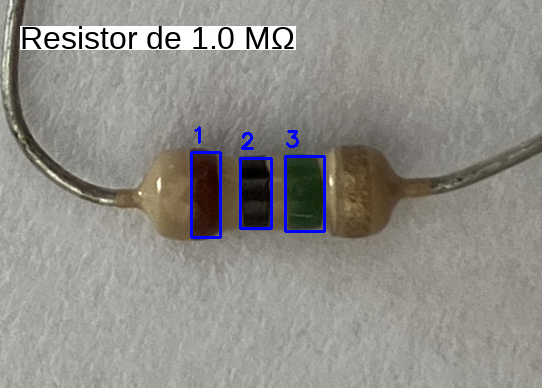

In [ ]:


img_pil = Image.fromarray(cv2.cvtColor(zoom, cv2.COLOR_BGR2RGB))

draw = ImageDraw.Draw(img_pil)
font = ImageFont.truetype(
    "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf", #Essa fonte funciona apenas no Colab
    32
)

draw.text((20, 20), f'Resistor de {resValue}', font=font, fill=(0,0,0))


texto = f'Resistor de {resValue}'

bbox = draw.textbbox((20, 20), texto, font=font)

draw.rectangle(
    bbox,
    fill="white"
)

draw.text(
    (20, 20),
    texto,
    font=font,
    fill="black"
)

zoom = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

cv2_imshow(zoom)
